In [1]:
import torch 
import torchvision 

from torch import nn 
from torchvision import datasets , transforms 
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
])

train_data=datasets.MNIST(root="./MNIST_data",train=True,download=True,transform=transform)
test_data=datasets.MNIST(root='./MNIST_data',train=False,download=True,transform=transform)

train_loader=torch.utils.data.DataLoader(train_data,batch_size=32,shuffle=True)
test_loader=torch.utils.data.DataLoader(test_data,batch_size=32)

In [5]:
class Mnist_Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.convo=nn.Sequential(
            nn.Conv2d(1,24,2),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(24,48,2),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.Clasifier=nn.Sequential(
            nn.Flatten(),
            nn.Dropout((0.5)),
            nn.Linear(48*6*6,128),
            nn.ReLU(),
            nn.Linear(128,10)
        )
    def forward(self,x):
        x=self.convo(x)
        x=self.Clasifier(x)
        return x
    
Model=Mnist_Model()
import wandb 

wandb.init(project="Mnist Dataset" , name="Convucational neural network")
wandb.login(key="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")


loss_fun=nn.CrossEntropyLoss() # Loss function create 
optimizer=torch.optim.Adam(params=Model.parameters(),lr=0.01,weight_decay=0.01) # Optimizer create 
accuracy_list=[]
loss_li=[]
epochs=10

for epoch in range(10):
    for image , labels in train_loader: # Process the image and labels from train_loader 
        output=Model(image) # Output probability 
        loss=loss_fun(output,labels) # Loss calculate from output probability 
        loss_li.append(loss.item()) # Add loss in list 
        optimizer.zero_grad()
        loss.backward() # Loss backward 
        optimizer.step()
        pred=torch.argmax(output,dim=1) # Acuraccy predicted probability 
        accuracy_score=(pred==labels).float().mean()
        accuracy_list.append(accuracy_score.item())
        
        wandb.log({
            "epoch":epoch,
            "accuracy":accuracy_score.item(),
            "loss":loss.item()
        })
wandb.finish()

print(f'the epochs are : {epoch} and the loss is : {loss.item()*100:.4f} and the accuracy is : {accuracy_score.item()*100:.2f}%')

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


accuracy,▁█▇▇▆▇▇▇▆▇▇▅▇█▆▇▇▇▇▇▆▇▇▇▇▅▇▇▇▇▇▇▇▆██▇▇▇▆
epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▅▅▅▅▅▆▆▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇███
loss,▃▄▃▂▂▂▂▂█▃▂▂▁▃▂▂▅▅▇▃▁▃▅▁▄▆▃▃▅▂▂▂▁▃▂▂▅▂▄▁
accuracy,0.84375
epoch,9
loss,0.40284


the epochs are : 9 and the loss is : 40.2844 and the accuracy is : 84.38%


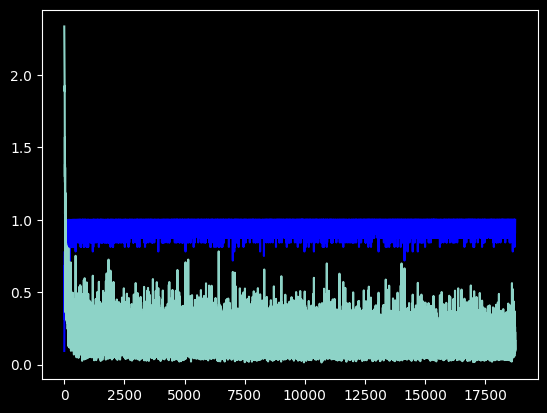

In [ ]:
import matplotlib.pyplot as plt 
plt.plot(accuracy_list,color='blue')
plt.plot(loss_li)
plt.style.use('dark_background')


In [ ]:
from torchinfo import summary
summary(Model,input_size=(1,1,28,28))


Layer (type:depth-idx)                   Output Shape              Param #
Mnist_Model                              [1, 10]                   --
├─Sequential: 1-1                        [1, 48, 6, 6]             --
│    └─Conv2d: 2-1                       [1, 24, 27, 27]           120
│    └─ReLU: 2-2                         [1, 24, 27, 27]           --
│    └─MaxPool2d: 2-3                    [1, 24, 13, 13]           --
│    └─Conv2d: 2-4                       [1, 48, 12, 12]           4,656
│    └─ReLU: 2-5                         [1, 48, 12, 12]           --
│    └─MaxPool2d: 2-6                    [1, 48, 6, 6]             --
├─Sequential: 1-2                        [1, 10]                   --
│    └─Flatten: 2-7                      [1, 1728]                 --
│    └─Dropout: 2-8                      [1, 1728]                 --
│    └─Linear: 2-9                       [1, 128]                  221,312
│    └─ReLU: 2-10                        [1, 128]                  --
│    └